In [ ]:
# ============================================================
#  GROUNDWATER LEVEL PREDICTION (2013–2024)
#  Machine Learning Regression Model Comparison
#  Author: Aaryan
# ============================================================

# --- 1. Import Required Libraries ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Load Dataset ---
# Replace the path with your uploaded CSV file path in Colab or Drive
df = pd.read_csv("/content/22070521127_ML_clean.csv")

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
df.head()

# --- 3. Basic Preprocessing ---
# Ensure correct datatypes
df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year.fillna(df['year']).astype(int)

# Drop rows with missing essential values
df = df.dropna(subset=['state_name', 'district_name', 'station_name', 'latitude', 'longitude', 'currentlevel'])
df = df.reset_index(drop=True)

print("📊 Dataset cleaned and ready for aggregation.")
print(f"Available years: {sorted(df['year'].unique())}")

✅ Data Loaded Successfully!
Shape: (13021, 11)
📊 Dataset cleaned and ready for aggregation.
Available years: [np.int64(1970)]


In [ ]:
# --- 4. Aggregate to Station-Year Level ---
agg_df = (
    df.groupby(['state_name', 'district_name', 'station_name', 'latitude', 'longitude', 'year'])
    .agg({'currentlevel': 'mean', 'level_diff': 'mean'})
    .reset_index()
)

print("✅ Aggregated Dataset (Station-Year Level):")
print(agg_df.head())

# --- 5. Feature Encoding ---
features = ['year', 'state_name', 'district_name', 'station_name', 'latitude', 'longitude', 'level_diff']
target = 'currentlevel'

X = agg_df[features]
y = agg_df[target]

# encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
# X[['state_name', 'district_name', 'station_name']] = encoder.fit_transform(
#     X[['state_name', 'district_name', 'station_name']]
# )

✅ Aggregated Dataset (Station-Year Level):
                    state_name             district_name         station_name  \
0  Andaman And Nicobar Islands  North And Middle Andaman            Bakultala   
1  Andaman And Nicobar Islands  North And Middle Andaman  Baratang (Nilambur)   
2  Andaman And Nicobar Islands  North And Middle Andaman           Basantipur   
3  Andaman And Nicobar Islands  North And Middle Andaman              Betapur   
4  Andaman And Nicobar Islands  North And Middle Andaman             Durgapur   

   latitude  longitude  year  currentlevel  level_diff  
0  12.50389   92.85917  1970      0.913333   -0.014167  
1  12.16694   92.76556  1970      1.090833    0.056667  
2  12.72917   92.88472  1970      1.336923    0.167692  
3  12.62222   92.87278  1970      1.285000    0.054000  
4  13.23083   92.95528  1970      0.858333    0.035833  


In [ ]:
# --- 6. Train–Validation Split (Temporal) ---
train_data = agg_df[agg_df['year'] <= 2022].copy()
test_data  = agg_df[agg_df['year'] == 2023].copy()

# Fallback: if no 2023 data exists, sample 20% of the latest year as test
if test_data.empty:
    latest_year = agg_df['year'].max()
    print(f"⚠️ No 2023 data found! Using {latest_year} data for validation instead.")
    test_data = agg_df[agg_df['year'] == latest_year].sample(frac=0.2, random_state=42)

# Split features and target
X_train = train_data[features].copy()
y_train = train_data[target].copy()
X_test  = test_data[features].copy()
y_test  = test_data[target].copy()

# Encode categorical features safely
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[['state_name', 'district_name', 'station_name']] = encoder.fit_transform(
    X_train[['state_name', 'district_name', 'station_name']]
)

X_test[['state_name', 'district_name', 'station_name']]  = encoder.transform(X_test[['state_name', 'district_name', 'station_name']])

print(f"✅ Training set: {X_train.shape}, Validation set: {X_test.shape}")

# --- 7. Train Models ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

metrics = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metrics[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"\n📈 {name} Results:")
    print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

# --- 8. Model Comparison ---
metrics_df = pd.DataFrame(metrics).T.sort_values("RMSE")
best_model_name = metrics_df.index[0]
best_model = models[best_model_name]

print("\n🏆 Best Model:", best_model_name)
metrics_df

⚠️ No 2023 data found! Using 1970 data for validation instead.
✅ Training set: (622, 7), Validation set: (124, 7)

📈 Linear Regression Results:
RMSE: 3.747 | MAE: 2.692 | R²: 0.277

📈 Random Forest Results:
RMSE: 1.037 | MAE: 0.692 | R²: 0.945

📈 Gradient Boosting Results:
RMSE: 1.853 | MAE: 1.426 | R²: 0.823

🏆 Best Model: Random Forest


,RMSE,MAE,R2
Random Forest,1.037434,0.691633,0.944590
Gradient Boosting,1.852891,1.425967,0.823246
Linear Regression,3.747007,2.691639,0.277167


/tmp/ipython-input-3106323795.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_2024_enc[['state_name', 'district_name', 'station_name']] = encoder.transform(



✅ 2024 Predictions Saved: predicted_groundwater_2024.csv


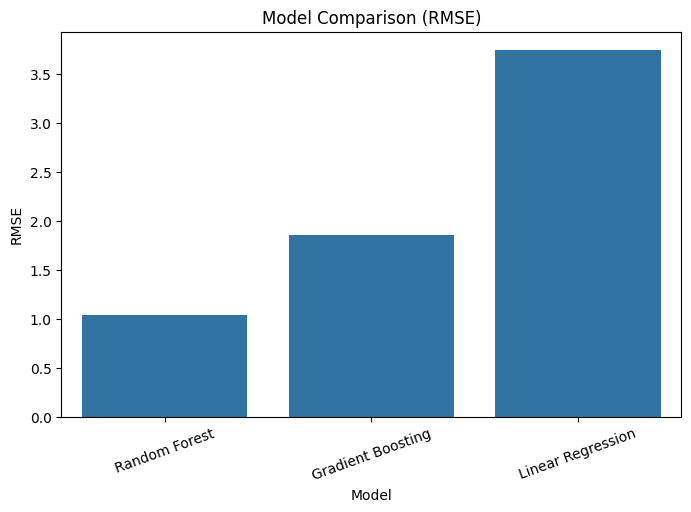


🔍 Sample 2024 Predictions:


,state_name,district_name,station_name,latitude,longitude,predicted_2024_currentlevel
607,West Bengal,South 24 Parganas,Ramdhari,22.32778,88.57917,4.614717
606,West Bengal,South 24 Parganas,Rajpur2,22.42667,88.40694,6.217850
605,West Bengal,South 24 Parganas,Rajpur A,22.42306,88.40361,5.811899
604,West Bengal,South 24 Parganas,Rajnagar2,21.67139,88.25139,7.077131
603,West Bengal,South 24 Parganas,Rajar taluk,22.23167,88.11111,3.034829
602,West Bengal,South 24 Parganas,Rajar Taluk,22.17500,88.20361,2.991206
601,West Bengal,South 24 Parganas,Raidighi1,21.98333,88.43333,9.683301
600,West Bengal,South 24 Parganas,Raidighi,21.98333,88.43333,10.413318
599,West Bengal,South 24 Parganas,Radhakantapur,22.06667,88.45833,7.412642
598,West Bengal,South 24 Parganas,Purba Bhangankhali,22.28972,88.69861,3.580916


In [ ]:
# --- 9. Prepare 2024 Data ---
latest_info = agg_df.sort_values('year').groupby('station_name').tail(1)
X_2024 = latest_info.copy()
X_2024['year'] = 2024
X_2024['level_diff'] = X_2024['level_diff'].fillna(0)

X_2024_enc = X_2024[features]
X_2024_enc[['state_name', 'district_name', 'station_name']] = encoder.transform(
    X_2024_enc[['state_name', 'district_name', 'station_name']]
)

# --- 10. Predict 2024 Levels ---
y_pred_2024 = best_model.predict(X_2024_enc)
pred_2024_df = X_2024[['state_name', 'district_name', 'station_name', 'latitude', 'longitude']].copy()
pred_2024_df['predicted_2024_currentlevel'] = y_pred_2024

# --- 11. Save & Display ---
pred_2024_df.to_csv("/content/predicted_groundwater_2024.csv", index=False)
print("\n✅ 2024 Predictions Saved: predicted_groundwater_2024.csv")

# --- 12. Visualization (Optional) ---
plt.figure(figsize=(8,5))
sns.barplot(x=metrics_df.index, y='RMSE', data=metrics_df)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.show()

print("\n🔍 Sample 2024 Predictions:")
pred_2024_df.head(10)

In [ ]:
# import joblib

# # Save models
# joblib.dump(RandomForestRegressor, "regression_model.pkl")

# # Download
# from google.colab import files
# files.download("regression_model.pkl")


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import joblib

# Train model (example)
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# ✅ Save trained model instance
joblib.dump(regressor, "regression_model.pkl")
print("✅ Model trained and saved successfully!")


✅ Model trained and saved successfully!


In [ ]:
joblib.dump(encoder, "encoder.pkl")
print("✅ Encoder saved successfully!")


✅ Encoder saved successfully!
